# Dimensionalitetsreducering & klustring - California Housing Dataset

---

## 6 Oövervakad inlärning 

### Bakgrund (case)

Ledningen vill inte bara ha en modell - de vill också förstå om det finns **naturliga grupper av områden** i datan. Om sådana grupper finns kan det hjälpa till att:

- Segmentera områden (t.ex. "typområden" som liknar varandra)
- Upptäcka ovanliga områden (avvikare)
- Och få en enklare överblick i datan innan man tar beslut

### Uppdrag

Du ska därför undersöka om datan verkar innehålla struktur genom att använda **PCA eller KMEANS** på ett rimligt urval av X-variabler (inte target)

### Syfte

Att se om vi kan:

- Sammanfatta datan i ett enklare "mönster" (PCA) eller
- Hitta grupper av liknande områden (KMeans)
- Och diskutera hur detta skulle kunna användas som beslutsstöd

### Krav

- Implementera PCA **eller** KMeans
- Visa resultat (figur/tabell)
- Tolka kort: vad kan vi lära oss, och vad är osäkert?

Använd endast X-variabler (inte target) och motivera kort vilka features du inkluderade. Kom ihåg att metoderna är känsliga för skalning. 

## Importera bibliotek

In [1]:
# Grundläggande bibliotek för datahantering & visualisering

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Scikit-learn: preprocessing & pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Scikit-learn: clustering

from sklearn.cluster import KMeans

# Scikit-learn: dimension reduction

from sklearn.decomposition import PCA

# Scikit-learn: modellval & utvärdering

from sklearn.metrics import silhouette_score

## EDA & dataförberedelse

### Läsa in datan & ta bort target

In [2]:
df = pd.read_csv("../data/housing.csv")

# df.head(5)

In [3]:
df = df.drop(columns=["median_house_value"])

# df.head(5)

### Ocean Proximity

In [4]:
df["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

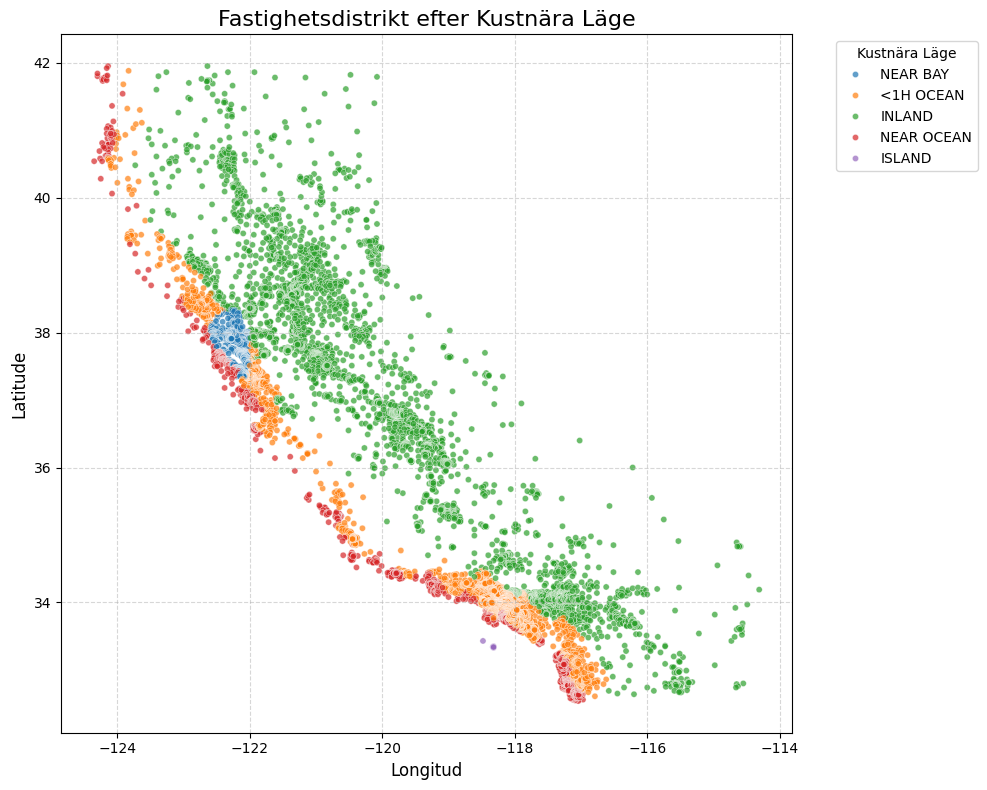

In [5]:
plt.figure(figsize=(10, 8))

sns.scatterplot(data=df, x="longitude", y="latitude", hue="ocean_proximity", palette="tab10", alpha=0.7, s=20)
plt.title("Fastighetsdistrikt efter Kustnära Läge", fontsize=16)
plt.xlabel("Longitud", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(title="Kustnära Läge", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#### OrdinalEncoder

In [6]:
ordered_categories = ["INLAND", "<1H OCEAN", "NEAR BAY", "NEAR OCEAN", "ISLAND"]

encoder = OrdinalEncoder(categories=[ordered_categories])

df["ocean_proximity"] = encoder.fit_transform(df[["ocean_proximity"]])

In [7]:
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,2.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,2.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,2.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,2.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,2.0


### Feature Engineering & städning

In [8]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]
df["population_per_household"] = df["population"] / df["households"]

df_clean = df.drop(columns=[
    "total_rooms", 
    "total_bedrooms", 
    "population", 
    "households",
    "longitude",
    "latitude"
])

df_clean.head(5)

,housing_median_age,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,41.0,8.3252,2.0,6.984127,0.146591,2.555556
1,21.0,8.3014,2.0,6.238137,0.155797,2.109842
2,52.0,7.2574,2.0,8.288136,0.129516,2.802260
3,52.0,5.6431,2.0,5.817352,0.184458,2.547945
4,52.0,3.8462,2.0,6.281853,0.172096,2.181467


### Hantera saknade värden

In [9]:
missing_values_table = pd.DataFrame({
    "Saknade värden": df_clean.isna().sum(),
    "Procent (%)": ((df_clean.isna().sum() / len(df)) * 100).round(2)
})

print(missing_values_table)

                          Saknade värden  Procent (%)
housing_median_age                     0          0.0
median_income                          0          0.0
ocean_proximity                        0          0.0
rooms_per_household                    0          0.0
bedrooms_per_room                    207          1.0
population_per_household               0          0.0


In [10]:
imputer = SimpleImputer(strategy="median")

df_clean = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns
)

# df_clean.isna().sum()

### Outliers

In [11]:
df_clean.describe()

,housing_median_age,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,3.870671,1.051841,5.429000,0.212940,3.070655
std,12.585558,1.899822,0.971081,2.474173,0.057700,10.386050
min,1.000000,0.499900,0.000000,0.846154,0.100000,0.692308
25%,18.000000,2.563400,0.000000,4.440716,0.175708,2.429741
50%,29.000000,3.534800,1.000000,5.229129,0.203162,2.818116
75%,37.000000,4.743250,1.000000,6.052381,0.239273,3.282261
max,52.000000,15.000100,4.000000,141.909091,1.000000,1243.333333


### De mest extrema & brytpunkter

In [12]:
df_clean[df_clean["population_per_household"] > 15][
    ["population_per_household", "rooms_per_household"]
].sort_values(by="population_per_household", ascending=False)

,population_per_household,rooms_per_household
19006,1243.333333,3.166667
3364,599.714286,5.142857
16669,502.461538,9.076923
13034,230.172414,8.275862
9172,83.171429,5.123810
12104,63.750000,7.600000
16420,51.400000,5.366667
8874,41.214286,7.285714
13366,33.952941,5.258824
5986,21.333333,4.500000


Brytpunkt: efter 83,17

In [13]:
df_clean[df_clean["rooms_per_household"] > 40][
    ["population_per_household", "rooms_per_household"]
].sort_values(by="rooms_per_household", ascending=False)

,population_per_household,rooms_per_household
1914,2.727273,141.909091
1979,2.400000,132.533333
12447,1.844444,62.422222
1913,2.333333,61.812500
11862,1.750000,59.875000
1912,2.076923,56.269231
9676,2.366071,52.848214
11707,2.333333,52.690476
2395,1.729730,50.837838
1240,2.484848,47.515152


Brytpunkt: efter 62,42

In [14]:
# Ta bort de mest extrema

df_clean = df_clean[
    (df_clean["population_per_household"] < 100) &
    (df_clean["rooms_per_household"] < 70)
]

# Kontroll 

# df_clean.describe()

### Scaling

In [15]:
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(df_clean)

X_scaled = pd.DataFrame(X_scaled_array, columns=df_clean.columns)

# X_scaled.head(5)

## PCA

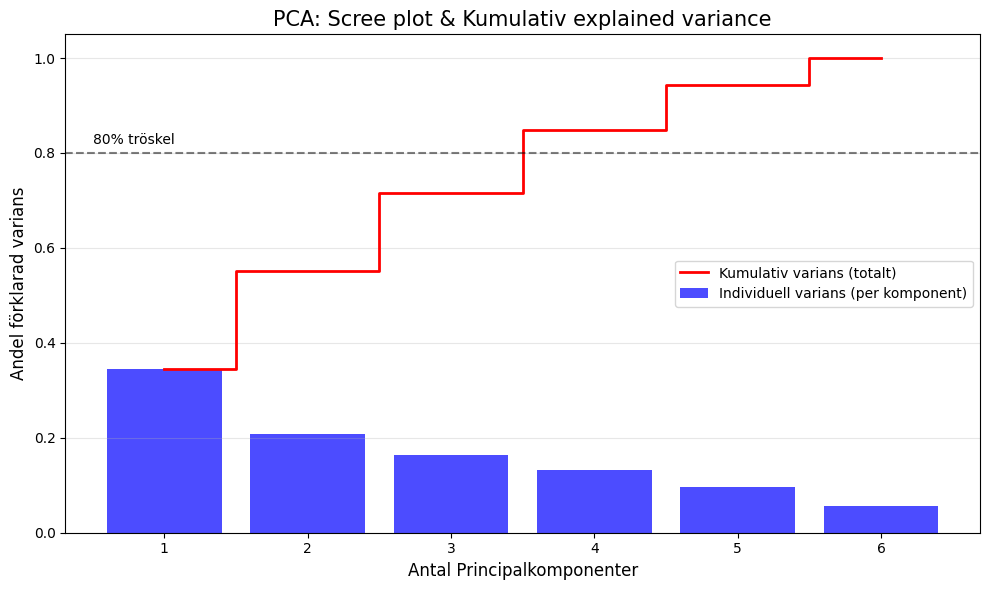

In [16]:
pca = PCA()
pca.fit(X_scaled)


explained_ratio = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained_ratio)

plt.figure(figsize=(10, 6))

plt.bar(range(1, len(explained_ratio) + 1), explained_ratio, alpha=0.7, align="center", label="Individuell varians (per komponent)", color="blue")

plt.step(range(1, len(cum_explained) + 1), cum_explained, where="mid", label="Kumulativ varians (totalt)", color="red", linewidth=2)

plt.axhline(y=0.8, color="black", linestyle="--", alpha=0.5)
plt.text(0.5, 0.82, "80% tröskel", color="black", fontsize=10)

plt.ylabel("Andel förklarad varians", fontsize=12)
plt.xlabel("Antal Principalkomponenter", fontsize=12)
plt.title("PCA: Scree plot & Kumulativ explained variance", fontsize=15)
plt.xticks(range(1, len(explained_ratio) + 1))
plt.legend(loc="center right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

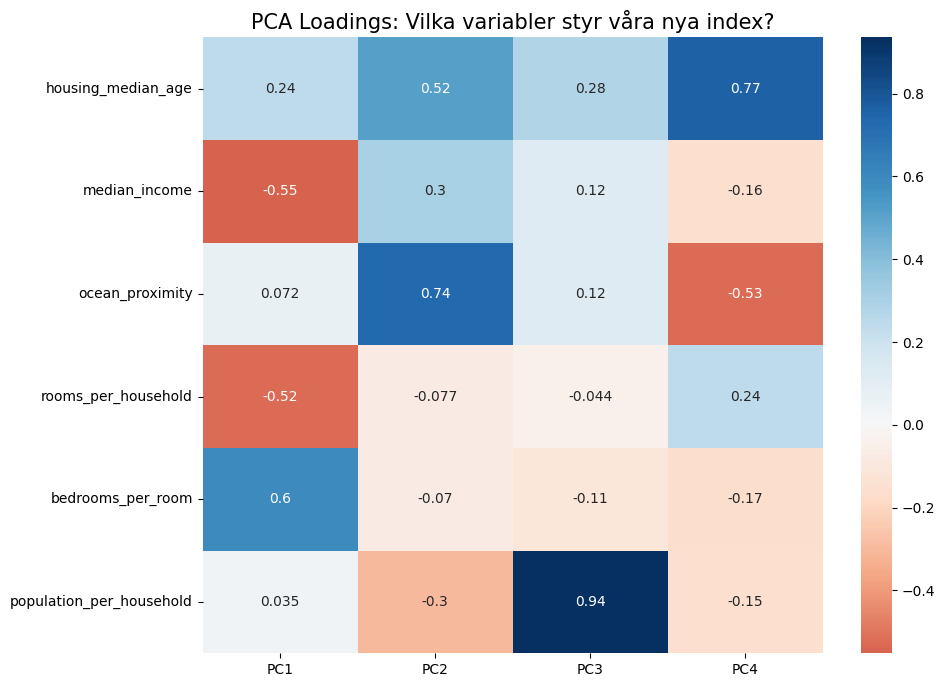

In [17]:
loadings = pd.DataFrame(
    pca.components_[:4].T,
    columns=["PC1", "PC2", "PC3", "PC4"],
    index=df_clean.columns
)

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu', center=0)
plt.title("PCA Loadings: Vilka variabler styr våra nya index?", fontsize=15)
plt.show()

## KMeans

In [18]:
X_pca = pca.transform(X_scaled)[:, :4]

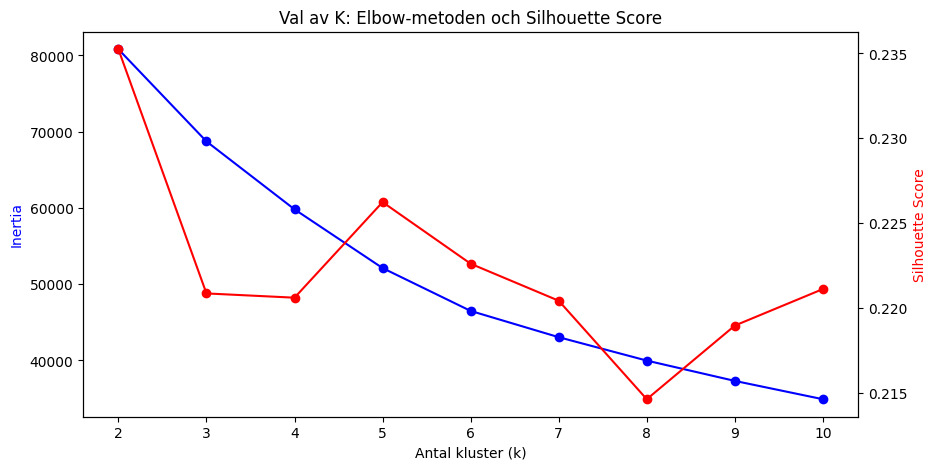

In [19]:
K_range = range(2, 11)
inertia = []
silhouette_avg = []


for k in K_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    
    inertia.append(kmeans.inertia_)
    
    silhouette_avg.append(silhouette_score(X_pca, cluster_labels))


fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertia, "bo-", label="Inertia (Elbow)")
ax1.set_xlabel("Antal kluster (k)")
ax1.set_ylabel("Inertia", color="b")

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_avg, "ro-", label="Silhouette Score")
ax2.set_ylabel("Silhouette Score", color="r")

plt.title("Val av K: Elbow-metoden och Silhouette Score")
plt.show()

In [20]:
K_table = {}

for k in [3, 4, 5, 6]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_pca)

    counts = pd.Series(cluster_labels).value_counts().sort_index()
    K_table[f"k={k}"] = counts

df_K_table = pd.DataFrame(K_table).fillna(0).astype(int)
df_K_table.index.name = "cluster"
df_K_table

,k=3,k=4,k=5,k=6
cluster,,,,
0,7918,7953,6761,3197
1,5418,5422,3363,5
2,7298,5,4526,3567
3,0,7254,5,3137
4,0,0,5979,5250
5,0,0,0,5478


In [21]:
final_kmeans = KMeans(n_clusters=5, init="k-means++", n_init=10, random_state=42)
cluster_labels = final_kmeans.fit_predict(X_pca)

df_clean["segment"] = cluster_labels

cluster_profile = df_clean.groupby("segment").mean()

print("Marknadssegmentens Profiler (Medelvärden)")
display(cluster_profile.T)

Marknadssegmentens Profiler (Medelvärden)


segment,0,1,2,3,4
housing_median_age,20.858157,21.368718,33.111578,25.400000,38.133133
median_income,3.276706,6.828258,2.309326,5.041480,4.058129
ocean_proximity,0.276882,1.190306,1.174105,0.200000,1.758990
rooms_per_household,5.502161,7.596322,3.857177,6.127003,5.271733
bedrooms_per_room,0.203832,0.152779,0.286287,0.170811,0.201595
population_per_household,2.870292,2.978356,3.302115,54.697731,2.702190


In [22]:
# Visa de 5 raderna som tillhör Segment 3
display(df_clean[df_clean['segment'] == 3])

,housing_median_age,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,segment
8874,52.0,9.3370,1.0,7.285714,0.166667,41.214286,3
9172,5.0,4.2391,0.0,5.123810,0.182156,83.171429,3
12104,8.0,1.6250,0.0,7.600000,0.125000,63.750000,3
13366,36.0,4.2578,0.0,5.258824,0.212528,33.952941,3
16420,26.0,5.7485,0.0,5.366667,0.167702,51.400000,3
